# Rabi Oscillations

## Overview

In this notebook we demonstrate Rabi oscillations using the circuit model of quantum computing.

We will:

1. Review the theoretical expression for excited-state probability.
2. Implement a single-qubit rotation $R_x(\theta)$.
3. Compare analytic and simulated probabilities.
4. Explore the effect of noise such as T1 relaxation.
5. Estimate execution cost on quantum hardware.

The goal is to connect the physical concept of driven two-level dynamics with its circuit-level implementation.

## Physical Background

Rabi oscillations describe coherent population transfer in a driven two-level system.

In the circuit model, this corresponds to a rotation about the $x$-axis:

$$
R_x(\theta) = e^{-i \theta X / 2}
$$

If the system begins in $|0\rangle$, applying $R_x(\theta)$ yields

$$
P(|1\rangle) = \sin^2\left(\frac{\theta}{2}\right)
$$

Physically, we can interpret $\theta = \Omega t$, where:

- $\Omega$ is the Rabi frequency,
- $t$ is interaction time.

Sweeping $\theta$ therefore produces oscillatory population transfer.

## Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from braket.devices import LocalSimulator
from braket.tracking import Tracker
from braket.circuits import Circuit, ResultType

from braket.experimental.algorithms.rabi_oscillations import rabi_probability, rabi_circuit


tracker = Tracker().start()  # to track Braket costs

## Constructing the Circuit

We generate a single-qubit circuit implementing $R_x(\theta)$.

In [55]:
theta_example = np.pi / 3
circ = rabi_circuit(theta_example)
print(circ.diagram())


T  : │     0      │
      ┌──────────┐ 
q0 : ─┤ Rx(1.05) ├─
      └──────────┘ 
T  : │     0      │


## Sweeping the Rotation Angle

We vary $\theta$ from $0$ to $2\pi$ and compute the expected analytic probability.

In [8]:
# Sweep angles from 0 to 2π
thetas = np.linspace(0, 2 * np.pi, 101)

# Analytic prediction
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

## Ideal Simulation (Exact Probability)

Using the simulator in analytic mode (`shots=0`), we compute the exact excited-state probability.

In [9]:
device = LocalSimulator()

def p1_from_result_type(theta: float) -> float:
    circ = rabi_circuit(theta)
    circ.add_result_type(ResultType.Probability(target=[0]))
    task = device.run(circ, shots=0)  # analytic mode
    result = task.result()
    probs = result.result_types[0].value  # [P(|0>), P(|1>)]
    return float(probs[1])

p1_sim_exact = np.array([p1_from_result_type(theta) for theta in thetas])

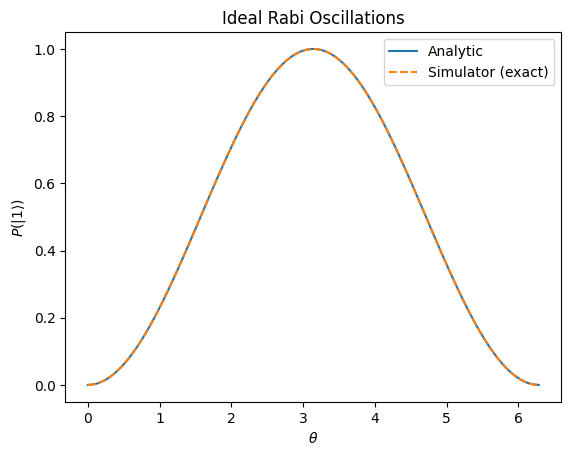

In [10]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_exact, linestyle="--", label="Simulator (exact)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Ideal Rabi Oscillations")
plt.legend()
plt.show()

### Interpretation

The simulator result matches the analytic curve exactly.

This confirms that the circuit correctly implements the rotation $R_x(\theta)$ and reproduces ideal Rabi oscillations.

## Sampled Simulation (Finite Shots)

In practice, measurements are sampled. We now estimate the probability using a finite number of shots.

In [11]:
def p1_from_sampling(theta: float, shots: int = 1000) -> float:
    circ = rabi_circuit(theta)
    task = device.run(circ, shots=shots)
    result = task.result()
    counts = result.measurement_counts  # dict like {"0": n0, "1": n1}
    n1 = counts.get("1", 0)
    return n1 / shots

shots = 1000
p1_sim_sampled = np.array([p1_from_sampling(theta, shots=shots) for theta in thetas])

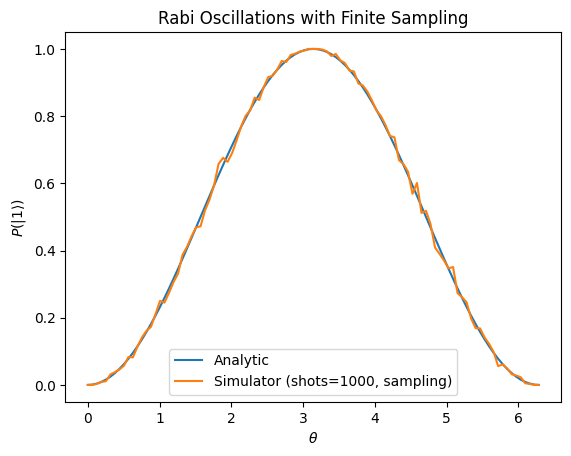

In [12]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_sampled, label=f"Simulator (shots={shots}, sampling)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with Finite Sampling")
plt.legend()
plt.show()

### Interpretation

Finite sampling introduces statistical fluctuations.  
As the number of shots increases, the sampled curve converges to the analytic prediction.

## Measurement Statistics at a Specific Angle

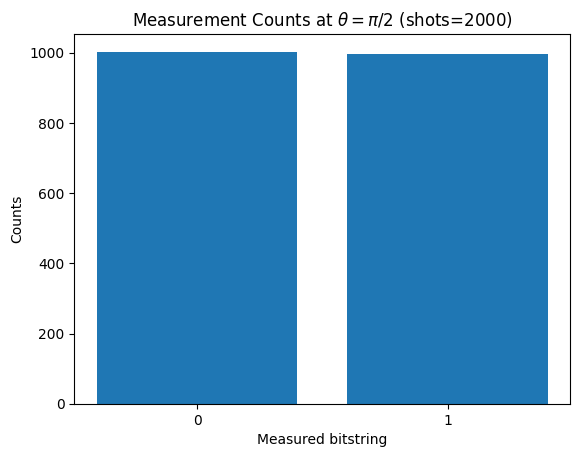

In [13]:
theta_hist = np.pi / 2
shots_hist = 2000

result = device.run(rabi_circuit(theta_hist), shots=shots_hist).result()
counts = result.measurement_counts

plt.figure()
plt.bar(list(counts.keys()), list(counts.values()))
plt.xlabel("Measured bitstring")
plt.ylabel("Counts")
plt.title(rf"Measurement Counts at $\theta=\pi/2$ (shots={shots_hist})")
plt.show()

### Interpretation

At $\theta = \pi/2$, the analytic prediction gives

$$
P(|1\rangle) = \sin^2\left(\frac{\pi}{4}\right) = \frac{1}{2}.
$$

This means the system is in an equal superposition of $|0\rangle$ and $|1\rangle$.

The histogram shows approximately equal counts for the two measurement outcomes.
Small deviations from perfect balance arise from finite sampling statistics.

As the number of shots increases, the observed distribution converges to the theoretical 50/50 split.

## T1 Relaxation: Single Damping Channel

We first model T1 relaxation using a simple circuit-level picture. After applying the rotation $R_x(\theta)$, we apply a single amplitude damping channel.

This model is easy to interpret: larger damping suppresses the excited-state population $P(|1\rangle)$, while the overall oscillation shape remains unchanged.

In [56]:
device_dm = LocalSimulator("braket_dm")

In [41]:
def rabi_circuit_t1_simple(theta: float, gamma: float) -> Circuit:
    circ = Circuit()
    circ.rx(0, theta)
    circ.amplitude_damping(0, gamma)
    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [42]:
def p1_from_t1_simple(theta: float, gamma: float) -> float:
    circ = rabi_circuit_t1_simple(theta, gamma)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [ ]:
gamma_values_t1_simple = [0.02, 0.1, 0.5]

p1_t1_simple = {
    gamma: np.array([p1_from_t1_simple(theta, gamma) for theta in thetas])
    for gamma in gamma_values_t1_simple
}

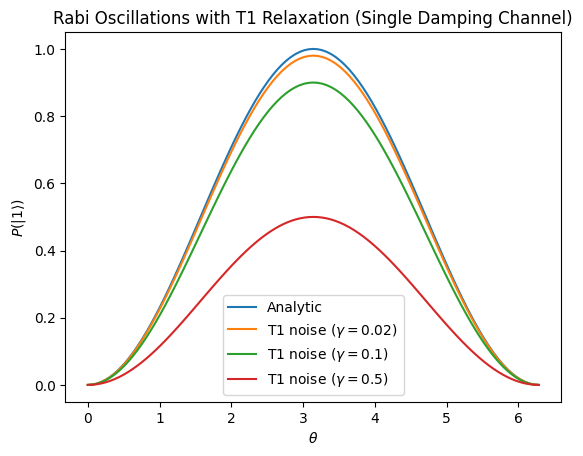

In [51]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t1:
    plt.plot(thetas, p1_t1_simple[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Single Damping Channel)")
plt.legend()
plt.show()

### Interpretation

In this simple model, T1 relaxation reduces the amplitude of the Rabi oscillation. For small $\gamma$, the effect is weak, while for large $\gamma$ the excited-state population is strongly suppressed.

This is a useful first approximation, but it does not yet describe relaxation acting continuously during the driven evolution.

## T1 Relaxation: Stepwise Model

We now use a more realistic model in which the drive and the relaxation act repeatedly throughout the evolution.

To approximate continuous-time dynamics, we divide the total rotation into many small steps. After each small rotation, we apply a small amplitude damping channel. This allows the coherent drive and the T1 process to compete during the evolution.

In [75]:
import math
from braket.circuits import Circuit, ResultType

def rabi_circuit_t1_stepwise(theta: float, gamma: float, dtheta: float = 0.05) -> Circuit:
    circ = Circuit()

    # number of steps needed
    n_steps = max(1, math.ceil(theta / dtheta))

    # adjust step size so steps sum exactly to theta
    dtheta_eff = theta / n_steps
    gamma_step = gamma / n_steps

    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.amplitude_damping(0, gamma_step)

    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [76]:
def p1_from_t1_stepwise(theta: float, gamma: float) -> float:
    circ = rabi_circuit_t1_stepwise(theta, gamma)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [77]:
gamma_values_t1_stepwise = [0.02, 0.1, 0.5]

p1_t1_stepwise = {
    gamma: np.array([p1_from_t1_stepwise(theta, gamma) for theta in thetas])
    for gamma in gamma_values_t1_stepwise
}

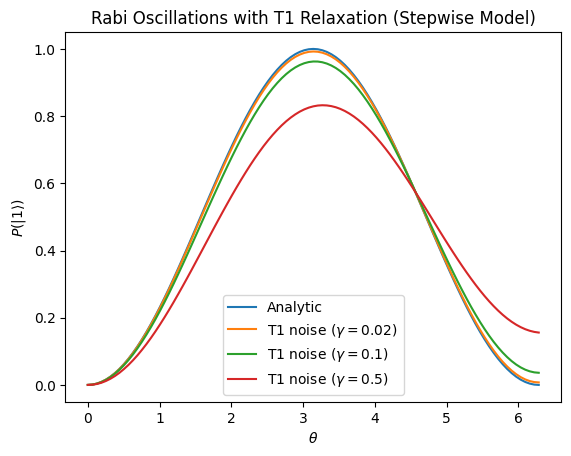

In [78]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t1:
    plt.plot(thetas, p1_t1_stepwise[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Stepwise Model)")
plt.legend()
plt.show()

### Interpretation

In the stepwise model, T1 relaxation acts continuously during the driven evolution rather than only once at the end.

As a result, the oscillation is not only suppressed but also distorted by the repeated competition between excitation and relaxation. This provides a more realistic picture of driven open-system dynamics.

## Resource Usage and Cost Tracking

Amazon Braket provides a built-in task tracker that estimates the cost of simulator and QPU tasks based on actual execution.

Below, we display:

- A summary of tasks executed in this notebook  
- The estimated total cost based on those tasks  

Note: These values are estimates and depend on actual device usage and current pricing.

In [ ]:
print("Task Summary")
print(f"{tracker.quantum_tasks_statistics()} \n")
print(
    f"Estimated cost to run this example: {tracker.qpu_tasks_cost() + tracker.simulator_tasks_cost():.2f} USD"
)

Task Summary
{} 

Estimated cost to run this example: 0.00 USD


### Interpretation

For local simulations, the estimated cost is typically zero or negligible.

If executed on a QPU, costs would depend on:

- The number of tasks submitted  
- The number of measurement shots  
- The selected hardware provider  

Always consult the official Amazon Braket pricing page for current rates.

In [ ]:
tracker.stop()